# Time Series Analysis on the data international Airline passengers form 1940 to 1960

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from statsmodels.tsa.seasonal import seasonal_decompose 


In [5]:
# load the dataset by reading the csv file
data = pd.read_csv('AirPassengers.csv')
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


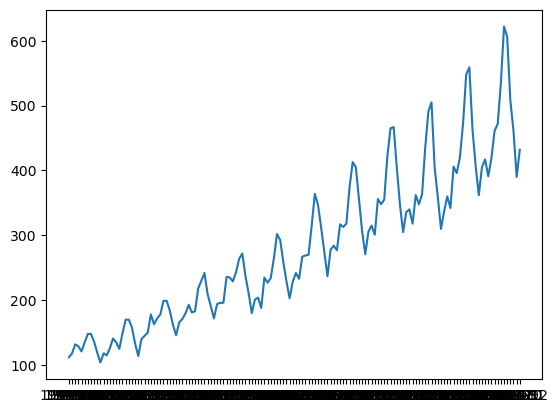

In [7]:
# now plot this data to see trands and seasonality x axis is month and y axis is number of passengers
plt.plot(data['Month'], data['#Passengers'])
plt.show()

C:\Users\Muhammad Asim\AppData\Local\Temp\ipykernel_10564\3567468761.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


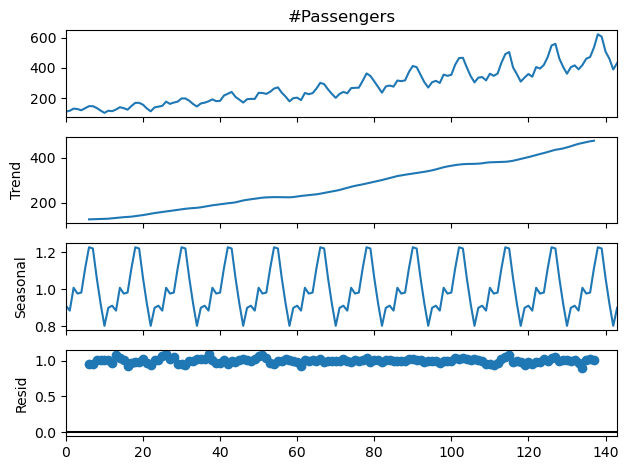

In [9]:
# decompose the data trend, seasonality, and residual
decomposition = seasonal_decompose(data['#Passengers'], model='multiplicative', period=12)
fig = decomposition.plot()
fig.show()

In [10]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


In [12]:
# split the data into training and testing sets
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]
# fit a simple linear regression model to the training data
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=(1,))
])
model.compile(optimizer='adam', loss='mse')
model.fit(train_data['Month'].values.reshape(-1, 1), train_data['#Passengers'].values, epochs=100)
# make predictions on the test data
predictions = model.predict(test_data['Month'].values.reshape(-1, 1))
# calculate the mean squared error
mse = np.mean((predictions - test_data['#Passengers'].values)**2)
print('Mean squared error:', mse)
# plot the actual and predicted values
plt.plot(test_data['Month'], test_data['#Passengers'], label='Actual')
plt.plot(test_data['Month'], predictions, label='Predicted')
plt.legend()
plt.show()

c:\Users\Muhammad Asim\miniconda3\envs\ml_python\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Invalid dtype: object